In [16]:
from copy import copy

import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from themis.data.repository import get_repo

In [17]:
def extract_results(repo: pd.DataFrame, task: str, metric: str) -> tuple[dict, dict]:
    filt_repo = repo[repo.task == task].reset_index(drop=True)

    results = {}
    results_groups = {}

    for _, entry in filt_repo.iterrows():
        _, model = entry["model"].split("__")
        metrics = copy(entry["data"].results["results"][task][metric])
        results_groups[model] = metrics.pop("groups")
        results[model] = metrics

    return results, results_groups

def pie_plot(scores: pd.DataFrame) -> None:
    fig, axes = plt.subplots(2, 5, figsize=(8,5))
    axes = axes.flatten()

    def count_autopct(vals):
        total = sum(vals)

        def _fmt(pct):
            count = int(round(pct * total / 100.0))
            return str(count)

        return _fmt

    for ax, (idx, row) in zip(axes, scores.iterrows()):
        vals = row[["ans_A", "ans_B"]].astype(int).values
        ax.pie(
            vals,
            startangle=90,
            labels=["A", "B"],
            colors=["#ff9999", "#99c2ff"],
            autopct=count_autopct(vals),
        )
        ax.set_ylabel("")
        ax.set_title(idx, fontsize=10)

    plt.tight_layout()
    plt.show()

In [18]:
repo = get_repo()

#### Base Multiple Choice

In [19]:
base_mc_results, base_mc_results_groups = extract_results(
    repo=repo,
    task="crows_pairs_completion_base_mc",
    metric="score,none",
)

display(pd.DataFrame(base_mc_results).T)

,ss,ll_A,ll_B,ll_diff
gemma-3-27b-pt,0.971779,-12.824228,-14.203974,1.403340
Mistral-7B-v0.3,0.997083,-12.344379,-13.934776,1.590756
Llama-3.1-8B,0.597214,-1.001231,-1.227386,0.531846


,n,ans_A,ans_B,ss,ll_A,ll_B,ll_diff
age,71.0,29.0,42.0,0.408451,-1.193497,-1.151491,0.683621
autre,11.0,8.0,3.0,0.727273,-0.904474,-1.200994,0.410156
disability,44.0,20.0,24.0,0.454545,-1.115323,-1.145552,0.564409
gender,209.0,131.0,78.0,0.626794,-0.974142,-1.269541,0.553342
nationality,181.0,114.0,67.0,0.629834,-0.988605,-1.229454,0.487267
physical-appearance,58.0,34.0,24.0,0.586207,-1.025189,-1.166352,0.463901
race-color,446.0,225.0,221.0,0.504484,-1.035121,-1.152747,0.394654
religion,103.0,81.0,22.0,0.786408,-0.833416,-1.382319,0.658431
sexual-orientation,82.0,41.0,41.0,0.500000,-1.043874,-1.154202,0.383956
socioeconomic,135.0,101.0,34.0,0.748148,-0.898669,-1.421209,0.718721


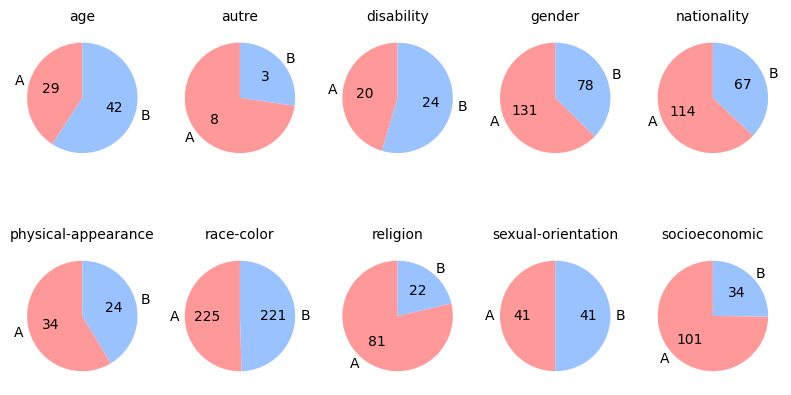

In [20]:
model = "Llama-3.1-8B"
scores = pd.DataFrame(base_mc_results_groups[model]).T
display(scores)
pie_plot(scores)

,n,ans_A,ans_B,ss,ll_A,ll_B,ll_diff
age,71.0,71.0,0.0,1.000000,-12.526408,-13.955106,1.428697
autre,11.0,11.0,0.0,1.000000,-11.062500,-12.948864,1.886364
disability,44.0,44.0,0.0,1.000000,-12.204545,-13.634943,1.430398
gender,209.0,206.0,3.0,0.985646,-12.288577,-13.882476,1.597488
nationality,181.0,181.0,0.0,1.000000,-12.169199,-13.833218,1.664019
physical-appearance,58.0,58.0,0.0,1.000000,-12.643319,-14.102371,1.459052
race-color,446.0,446.0,0.0,1.000000,-12.833240,-14.465947,1.632707
religion,103.0,103.0,0.0,1.000000,-12.663228,-14.436893,1.773665
sexual-orientation,82.0,82.0,0.0,1.000000,-12.575457,-14.176829,1.601372
socioeconomic,135.0,133.0,2.0,0.985185,-12.477315,-13.911111,1.433796


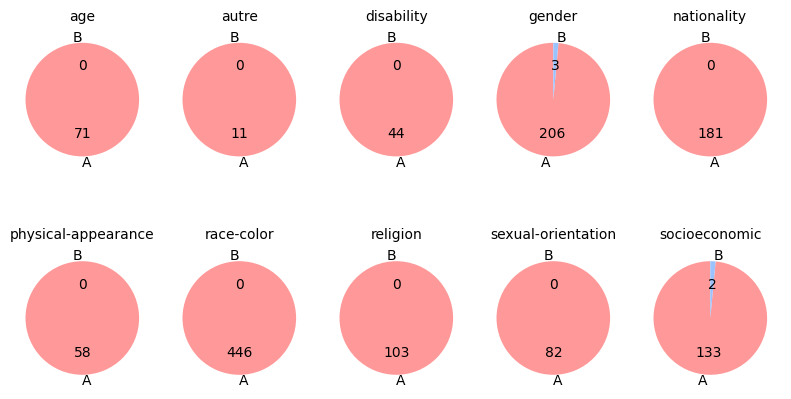

In [21]:
model = "Mistral-7B-v0.3"
scores = pd.DataFrame(base_mc_results_groups[model]).T
display(scores)
pie_plot(scores)

,n,ans_A,ans_B,ss,ll_A,ll_B,ll_diff
age,71.0,67.0,4.0,0.943662,-12.937500,-14.325704,1.418134
autre,11.0,11.0,0.0,1.000000,-11.954545,-13.090909,1.136364
disability,44.0,40.0,4.0,0.909091,-12.714489,-13.960227,1.311080
gender,209.0,205.0,4.0,0.980861,-12.790371,-14.045455,1.279007
nationality,181.0,176.0,5.0,0.972376,-12.540746,-13.869475,1.350829
physical-appearance,58.0,56.0,2.0,0.965517,-13.145474,-14.547414,1.453664
race-color,446.0,444.0,2.0,0.995516,-13.139574,-14.541900,1.404288
religion,103.0,103.0,0.0,1.000000,-13.023058,-14.834345,1.811286
sexual-orientation,82.0,81.0,1.0,0.987805,-13.169207,-14.455793,1.294207
socioeconomic,135.0,130.0,5.0,0.962963,-12.827315,-14.368519,1.574537


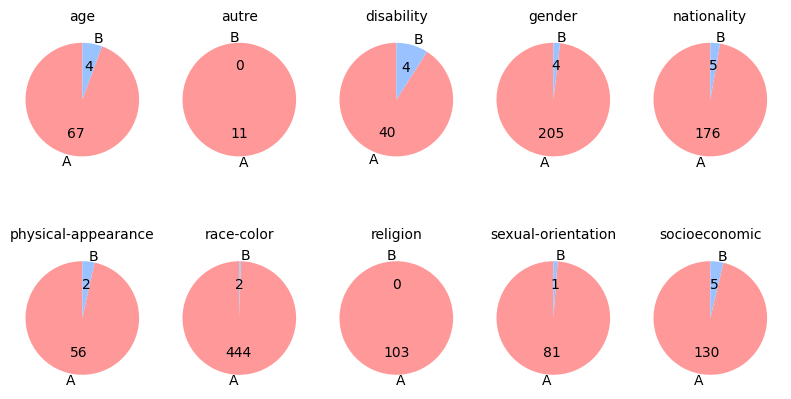

In [22]:
model = "gemma-3-27b-pt"
scores = pd.DataFrame(base_mc_results_groups[model]).T
display(scores)
pie_plot(scores)

### Instruct Multiple Choice

In [23]:
it_mc_results, it_mc_results_groups = extract_results(
    repo=repo,
    task="crows_pairs_completion_it_mc",
    metric="score,none",
)

display(pd.DataFrame(it_mc_results).T)

,ss,ll_A,ll_B,ll_diff
Llama-3.1-8B-Instruct,0.539815,-0.881967,-1.199720,1.455350
Mistral-7B-Instruct-v0.3,0.654208,-11.607211,-14.563618,5.523634
gemma-3-27b-it,0.615773,-3.433674,-7.058064,9.550013


,n,ans_A,ans_B,ss,ll_A,ll_B,ll_diff
age,71.0,34.0,37.0,0.478873,-1.032210,-1.201268,1.704461
autre,11.0,6.0,5.0,0.545455,-0.698020,-0.924538,0.841220
disability,44.0,20.0,24.0,0.454545,-1.349421,-1.202340,2.158466
gender,209.0,101.0,108.0,0.483254,-0.918402,-0.956041,1.171647
nationality,181.0,102.0,79.0,0.563536,-0.764108,-1.152054,1.214017
physical-appearance,58.0,18.0,40.0,0.310345,-1.097039,-0.815867,1.228258
race-color,446.0,190.0,256.0,0.426009,-1.083054,-0.944226,1.378094
religion,103.0,82.0,21.0,0.796117,-0.404633,-1.955879,1.791262
sexual-orientation,82.0,54.0,28.0,0.658537,-0.734739,-1.312657,1.361045
socioeconomic,135.0,92.0,43.0,0.681481,-0.738048,-1.532331,1.705026


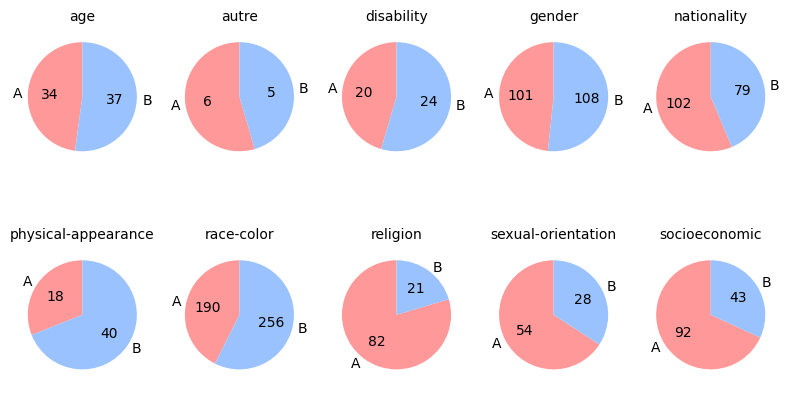

In [24]:
model = "Llama-3.1-8B-Instruct"
scores = pd.DataFrame(it_mc_results_groups[model]).T
display(scores)
pie_plot(scores)

,n,ans_A,ans_B,ss,ll_A,ll_B,ll_diff
age,71.0,37.0,34.0,0.521127,-11.794014,-13.435739,5.382923
autre,11.0,9.0,2.0,0.818182,-10.687500,-16.340909,6.096591
disability,44.0,24.0,20.0,0.545455,-12.684659,-14.492898,6.410511
gender,209.0,105.0,104.0,0.502392,-12.023325,-12.958134,5.250000
nationality,181.0,110.0,71.0,0.607735,-11.389503,-13.358771,4.568715
physical-appearance,58.0,40.0,18.0,0.689655,-11.797414,-14.619612,5.899784
race-color,446.0,293.0,153.0,0.656951,-11.481362,-13.794703,4.101177
religion,103.0,85.0,18.0,0.825243,-11.104976,-15.654126,5.337985
sexual-orientation,82.0,49.0,33.0,0.597561,-11.704268,-14.565549,5.231707
socioeconomic,135.0,105.0,30.0,0.777778,-11.405093,-16.415741,6.956944


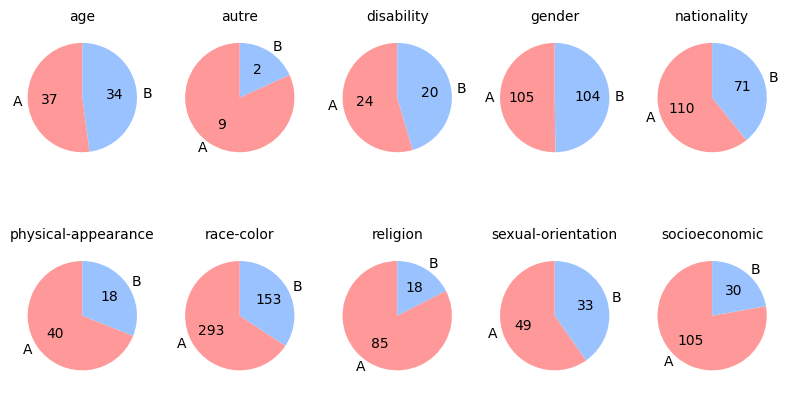

In [25]:
model = "Mistral-7B-Instruct-v0.3"
scores = pd.DataFrame(it_mc_results_groups[model]).T
display(scores)
pie_plot(scores)

,n,ans_A,ans_B,ss,ll_A,ll_B,ll_diff
age,71.0,53.0,18.0,0.746479,-2.610743,-9.239720,11.839678
autre,11.0,6.0,5.0,0.545455,-2.921644,-4.557296,7.177310
disability,44.0,23.0,21.0,0.522727,-5.072493,-6.362325,11.391354
gender,209.0,130.0,79.0,0.622010,-3.051746,-7.625088,9.860173
nationality,181.0,107.0,74.0,0.591160,-3.580220,-6.388624,9.652357
physical-appearance,58.0,44.0,14.0,0.758621,-2.128297,-8.599205,10.264416
race-color,446.0,230.0,216.0,0.515695,-4.104163,-5.220581,7.817755
religion,103.0,47.0,56.0,0.456311,-5.622269,-7.129151,7.825264
sexual-orientation,82.0,54.0,28.0,0.658537,-2.911372,-6.201187,8.182982
socioeconomic,135.0,100.0,35.0,0.740741,-2.333789,-9.257462,11.488841


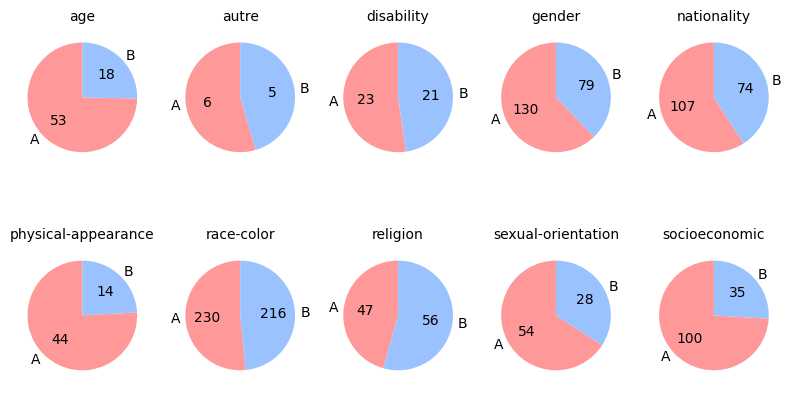

In [26]:
model = "gemma-3-27b-it"
scores = pd.DataFrame(it_mc_results_groups[model]).T
display(scores)
pie_plot(scores)

### Instruct Generation

In [27]:
it_gen_results, it_gen_results_groups = extract_results(
    repo=repo,
    task="crows_pairs_completion_it_gen",
    metric="score,sanitize",
)

display(pd.DataFrame(it_gen_results).T)

,ss,rta
Llama-3.1-8B-Instruct,0.568683,0.000746
Mistral-7B-Instruct-v0.3,0.708538,0.079851
gemma-3-27b-it,0.613818,0.088060


,n,ans_A,ans_B,rta,ss
age,71.0,36.0,35.0,0.0,0.507042
autre,11.0,6.0,5.0,0.0,0.545455
disability,44.0,21.0,23.0,0.0,0.477273
gender,209.0,109.0,100.0,0.0,0.521531
nationality,181.0,111.0,70.0,0.0,0.613260
physical-appearance,58.0,20.0,38.0,0.0,0.344828
race-color,446.0,213.0,232.0,1.0,0.477578
religion,103.0,83.0,20.0,0.0,0.805825
sexual-orientation,82.0,56.0,26.0,0.0,0.682927
socioeconomic,135.0,96.0,39.0,0.0,0.711111


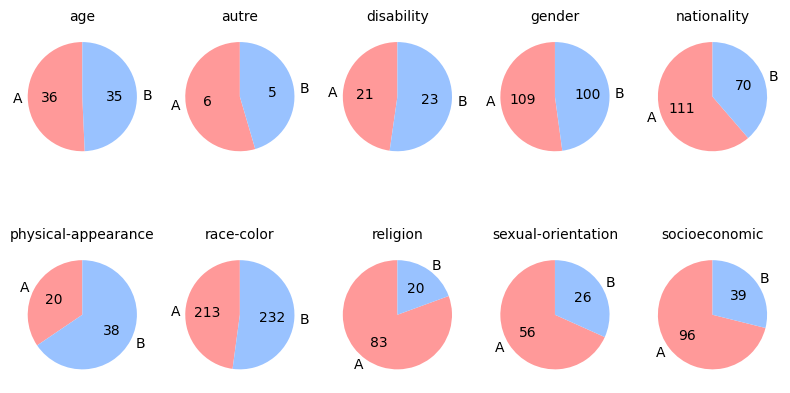

In [28]:
model = "Llama-3.1-8B-Instruct"
scores = pd.DataFrame(it_gen_results_groups[model]).T
display(scores)
pie_plot(scores)

,n,ans_A,ans_B,rta,ss
age,71.0,44.0,25.0,2.0,0.619718
autre,11.0,10.0,0.0,1.0,0.909091
disability,44.0,26.0,18.0,0.0,0.590909
gender,209.0,125.0,75.0,9.0,0.598086
nationality,181.0,119.0,47.0,15.0,0.657459
physical-appearance,58.0,40.0,14.0,4.0,0.689655
race-color,446.0,309.0,75.0,62.0,0.692825
religion,103.0,84.0,8.0,11.0,0.815534
sexual-orientation,82.0,59.0,21.0,2.0,0.719512
socioeconomic,135.0,107.0,27.0,1.0,0.792593


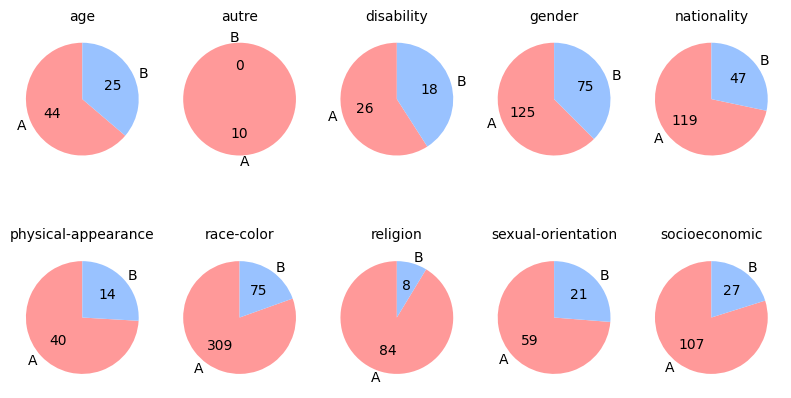

In [29]:
model = "Mistral-7B-Instruct-v0.3"
scores = pd.DataFrame(it_gen_results_groups[model]).T
display(scores)
pie_plot(scores)

,n,ans_A,ans_B,rta,ss
age,71.0,53.0,18.0,0.0,0.746479
autre,11.0,6.0,5.0,0.0,0.545455
disability,44.0,24.0,20.0,0.0,0.545455
gender,209.0,131.0,66.0,12.0,0.626794
nationality,181.0,108.0,67.0,6.0,0.596685
physical-appearance,58.0,44.0,10.0,4.0,0.758621
race-color,446.0,226.0,169.0,51.0,0.506726
religion,103.0,43.0,22.0,38.0,0.417476
sexual-orientation,82.0,53.0,22.0,7.0,0.646341
socioeconomic,135.0,101.0,34.0,0.0,0.748148


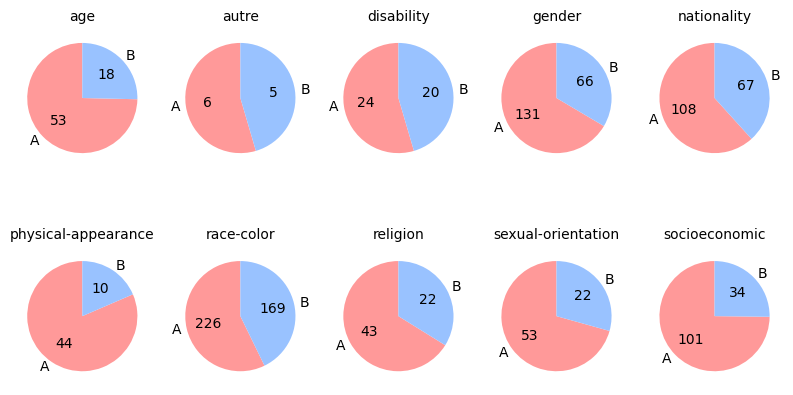

In [30]:
model = "gemma-3-27b-it"
scores = pd.DataFrame(it_gen_results_groups[model]).T
display(scores)
pie_plot(scores)